<a href="https://colab.research.google.com/github/V1LL4pro/Deep-Learning/blob/Corte-1/T2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DEEP LEARNING**

**UNIVERSIDAD MILITAR NUEVA GRANADA**

**DEEP LEARNING - REGRESIÓN LINEAL DESDE CERO**

Facultad de Ingeniería

# 1. Librerías

In [1]:
!pip install openpyxl

from google.colab import files
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
import random
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

# 2. Training data (Dataset)


In [2]:
# Subir el archivo Excel
subiditos = files.upload()

# Obtener nombre del archivo
archivito = next(iter(subiditos))

# Mostrar hojas disponibles
excelito = pd.ExcelFile(archivito)
print("\nHojas disponibles:", excelito.sheet_names)

# Seleccionar hoja
hojita_seleccionada = input("\nIngresa el nombre de la hoja a usar: ")

# Leer datos
dataframecito = pd.read_excel(archivito, sheet_name=hojita_seleccionada)

# 1. Eliminar valores nulos
dataframecito_limpio = dataframecito.replace([np.inf, -np.inf], np.nan).dropna()

# 2. Convertir columna de género
columnita_genero = dataframecito_limpio.columns[1]
dataframecito_limpio[columnita_genero] = dataframecito_limpio[columnita_genero].replace({
    'FEMENINO': 0,
    'MASCULINO': 1
})

# 3. Normalizacion
scaler = MinMaxScaler()
dataframecito_limpio_normalizado = scaler.fit_transform(dataframecito_limpio)

# 4. Convertir a tensor
#tensorcito = tf.convert_to_tensor(dataframecito_limpio_normalizado, dtype=tf.float32)
tensorcito = tf.convert_to_tensor(dataframecito_limpio, dtype=tf.float32) # Sin normalizacion

# 5. Separar características y etiquetas
features = tensorcito[:, 0:10]  # Características están en las primeras 10 columnas
labels = tensorcito[:, 11:12]

# 6. Dividir en entrenamiento y prueba (80/20 secuencial)
split_idx = int(0.8 * features.shape[0])  # Índice de división

# Datos de entrenamiento (primer 80%)
train_features = features[:split_idx]
train_labels = labels[:split_idx]

# Datos de prueba (último 20%)
test_features = features[split_idx:]
test_labels = labels[split_idx:]

Saving Diagnostico.xlsx to Diagnostico.xlsx

Hojas disponibles: ['Datos', 'Hoja2']

Ingresa el nombre de la hoja a usar: Datos


<ipython-input-2-9649e314ef0b>:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframecito_limpio[columnita_genero] = dataframecito_limpio[columnita_genero].replace({


In [3]:
# Mostrar ejemplos de features y columnas
print('train_features:', train_features[0:5],'\nlabel:', train_labels[0:5])

train_features: tf.Tensor(
[[ 19.       1.     181.      62.9     87.      90.      57.     124.
    4.1744  54.    ]
 [ 19.       1.     173.      75.7     83.      84.      46.     225.
    4.7185 156.6   ]
 [ 19.       1.     184.      78.5     75.      72.      52.     143.
    4.6347  70.4   ]
 [ 20.       1.     151.      52.2     87.      85.      53.     191.
    3.8918 128.2   ]
 [ 20.       0.     155.      53.1     87.      78.      58.     171.
    4.2047  99.6   ]], shape=(5, 10), dtype=float32) 
label: tf.Tensor(
[[1.37]
 [2.  ]
 [1.4 ]
 [1.13]
 [0.77]], shape=(5, 1), dtype=float32)


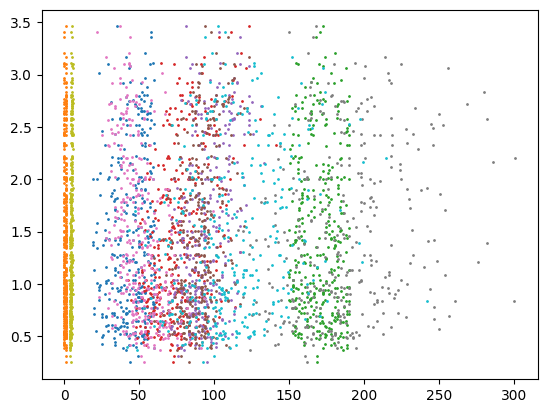

In [4]:
# Diagrama de dispersión de feature vs el label
plt.scatter(train_features[:, (0)].numpy(), train_labels.numpy(), 1)
plt.scatter(train_features[:, (1)].numpy(), train_labels.numpy(), 1)
plt.scatter(train_features[:, (2)].numpy(), train_labels.numpy(), 1)
plt.scatter(train_features[:, (3)].numpy(), train_labels.numpy(), 1)
plt.scatter(train_features[:, (4)].numpy(), train_labels.numpy(), 1)
plt.scatter(train_features[:, (5)].numpy(), train_labels.numpy(), 1)
plt.scatter(train_features[:, (6)].numpy(), train_labels.numpy(), 1)
plt.scatter(train_features[:, (7)].numpy(), train_labels.numpy(), 1)
plt.scatter(train_features[:, (8)].numpy(), train_labels.numpy(), 1)
plt.scatter(train_features[:, (9)].numpy(), train_labels.numpy(), 1)

# 3. Hiperparametros

In [5]:
# hiperparámetros
lr_inicial = 0.000015
lr_final = 0.000001
num_epochs = 31415 # los 5 primeros dijitos de pi :D
batch_size = 5

# 3. Lectura del dataset por lotes

Aleatorizar y leer por minilotes

In [6]:
def data_iter(batch_size, train_features, train_labels):
    num_examples = len(train_features)
    indices = list(range(num_examples))
    random.shuffle(indices)         # Leer de forma aleatoria los ejemplos
    for i in range(0, num_examples, batch_size):
        j = tf.constant(indices[i: min(i + batch_size, num_examples)])
        yield tf.gather(train_features, j), tf.gather(train_labels, j)

In [7]:
# Prueba de la lectura por minilotes
for X, y in data_iter(batch_size, train_features, train_labels):
    print(X, '\n', y)
    break

tf.Tensor(
[[ 51.       0.     159.      57.4    103.      80.      30.     217.
    4.8122 162.4   ]
 [ 43.       1.     189.      78.9     66.      80.      45.     134.
    4.0775  77.2   ]
 [ 37.       1.     158.      75.4     87.      87.      40.     166.
    5.0106  96.    ]
 [ 21.       1.     175.      74.1     76.      79.      53.     147.
    4.4427  77.    ]
 [ 37.       0.     154.      65.7     93.      88.      30.     180.
    5.0304 119.4   ]], shape=(5, 10), dtype=float32) 
 tf.Tensor(
[[0.91]
 [0.74]
 [0.52]
 [1.5 ]
 [1.42]], shape=(5, 1), dtype=float32)


# 4. Inicialización de parámetros

Prueba inicializando w a partir de una distribución normal de media cero y desviación estándar 0.01, y b en cero

In [8]:
w = tf.Variable(tf.random.normal(shape=(10, 1), mean=0, stddev=0.01),
                trainable=True)
b = tf.Variable(tf.zeros(1), trainable=True)

w

<tf.Variable 'Variable:0' shape=(10, 1) dtype=float32, numpy=
array([[-0.01500053],
       [-0.00028177],
       [-0.01521364],
       [ 0.00263633],
       [-0.00541008],
       [-0.01178021],
       [-0.0154721 ],
       [ 0.01340925],
       [ 0.00543064],
       [ 0.0160202 ]], dtype=float32)>

# 5. Modelo

Regresión lineal

Producto punto (matriz-vector) de las entradas (features $\mathbf{X}$) con los pesos del modelo ($\mathbf{w}$) más el offset ($b$)

In [9]:
# Modelo de regresión lineal
def reg_lineal(X, w, b):
    return tf.matmul(X, w) + b

# 6. Función de pérdida

Error cuadrático

In [10]:
# Pérdida por error cuadrático
def perd_cuad(y_hat, y):
    loss = (y_hat - tf.reshape(y, y_hat.shape)) ** 2 / 2
    return loss + 0.01 * tf.reduce_sum(w**2)  # L2 con lambda=0.01

# 7. Algoritmo de optimización

Minibatch stochastic gradient descent

Entradas: conjunto de parámetros, tasa de aprendizaje (learning rate), y el tamaño del lote (batch size)

In [11]:
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_inicial)

# 8. Entrenamiento

* Inicializar parámetros $(\mathbf{w}, b)$
* Repetir
    * Cálculo del gradiente $\mathbf{g} \leftarrow \partial_{(\mathbf{w},b)} \frac{1}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} l(\mathbf{x}^{(i)}, y^{(i)}, \mathbf{w}, b)$
    * Actualizar parámetros $(\mathbf{w}, b) \leftarrow (\mathbf{w}, b) - \eta \mathbf{g}$

En cada épocha (epoch) se itera todo el conjunto de datos

El número de épocas y la tasa de aprendizaje son hiperparámetros  

In [12]:
decay_rate = (lr_final / lr_inicial) ** (1/num_epochs)  # Decaimiento exponencial

net = reg_lineal
loss = perd_cuad

In [13]:
# entrenamiento
historia_train = []
historia_loss = []
for epoch in range(num_epochs):

    # Calcular lr actual para esta época ( decay lineal)
    lr = lr_inicial * (decay_rate ** epoch)
    historia_train.append(lr)

    for X, y in data_iter(batch_size, train_features, train_labels):
        with tf.GradientTape() as g:
            l = loss(net(X, w, b), y)           # Cálculo de función de pérdida en el minilote
        dw, db = g.gradient(l, [w, b])          # Cálculo del gradiente de la pérdida con respecto a w y b
        optimizer.apply_gradients(zip([dw, db], [w, b]))   # Actualizar parámetros utilizando el gradiente
    train_l = tf.reduce_mean(loss(net(train_features, w, b), train_labels))
    historia_loss.append(train_l)
    print(f'Época {epoch + 1}, pérdida {float(tf.reduce_mean(train_l)):f}, lr: {lr:.7f}')

Se truncaron las últimas líneas 5000 del resultado de transmisión.
Época 26416, pérdida 0.154292, lr: 0.0000015
Época 26417, pérdida 0.154550, lr: 0.0000015
Época 26418, pérdida 0.154426, lr: 0.0000015
Época 26419, pérdida 0.155562, lr: 0.0000015
Época 26420, pérdida 0.155184, lr: 0.0000015
Época 26421, pérdida 0.154388, lr: 0.0000015
Época 26422, pérdida 0.154535, lr: 0.0000015
Época 26423, pérdida 0.154314, lr: 0.0000015
Época 26424, pérdida 0.154529, lr: 0.0000015
Época 26425, pérdida 0.154473, lr: 0.0000015
Época 26426, pérdida 0.154295, lr: 0.0000015
Época 26427, pérdida 0.155346, lr: 0.0000015
Época 26428, pérdida 0.154354, lr: 0.0000015
Época 26429, pérdida 0.154598, lr: 0.0000015
Época 26430, pérdida 0.154334, lr: 0.0000015
Época 26431, pérdida 0.154317, lr: 0.0000015
Época 26432, pérdida 0.154652, lr: 0.0000015
Época 26433, pérdida 0.155044, lr: 0.0000015
Época 26434, pérdida 0.154807, lr: 0.0000015
Época 26435, pérdida 0.154343, lr: 0.0000015
Época 26436, pérdida 0.155801, lr

In [14]:
b

<tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([0.22722226], dtype=float32)>

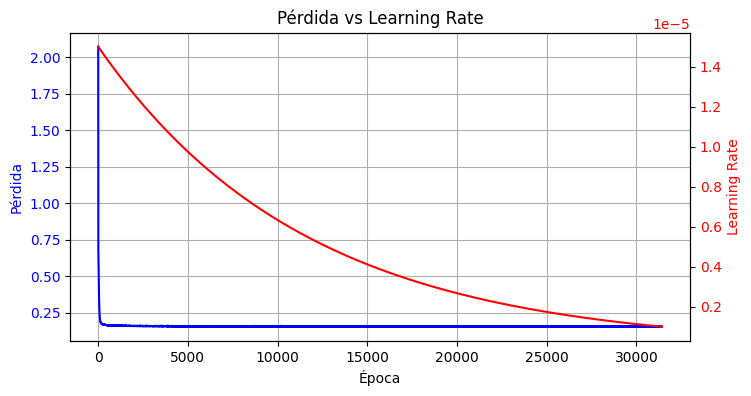

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(historia_loss, label="Pérdida", color="blue")
plt.xlabel("Época")
plt.ylabel("Pérdida", color="blue")
plt.tick_params(axis="y", labelcolor="blue")
plt.grid(True)

plt.twinx()
plt.plot(historia_train, label="Learning Rate", color="red")
plt.ylabel("Learning Rate", color="red")
plt.tick_params(axis="y", labelcolor="red")

plt.title("Pérdida vs Learning Rate")
plt.show()

In [22]:
min_loss = min(historia_loss)
min_loss_epoch = historia_loss.index(min_loss)
print(f"Valor mínimo de la pérdida: {min_loss:f} en la época {min_loss_epoch}")

Valor mínimo de la pérdida: 0.154193 en la época 31338


# Historico

*   F.perdida y A.optimizacion default, lr decay lineal a 1000 epocas.
*   Perdida 0.170





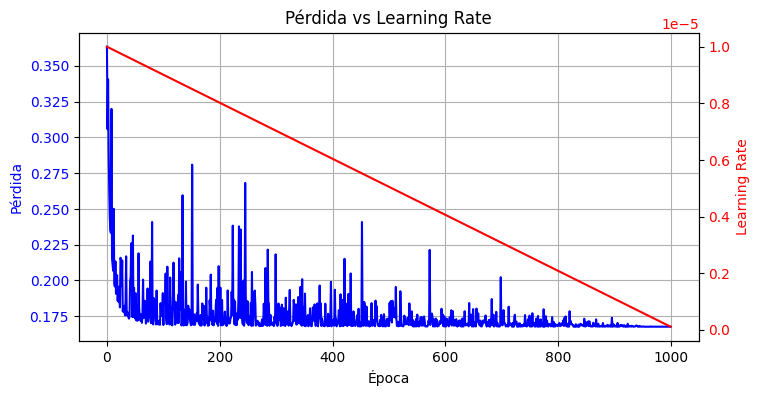

*   F.perdida regL2 y A.optimizacion default, lr decay lineal a 1000 epocas.
*   Perdida 0.169

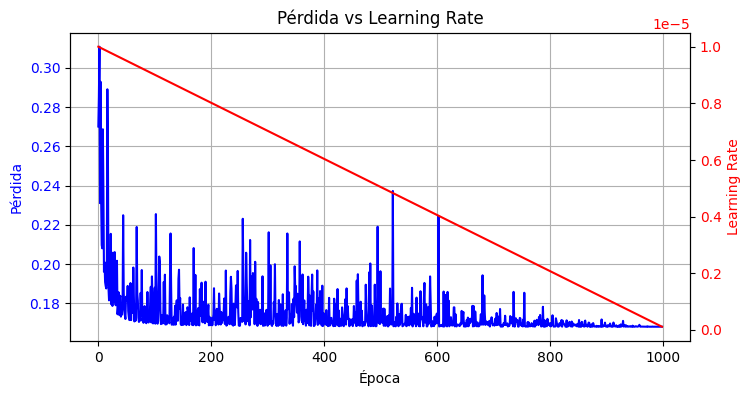

*   F.perdida regL2 y A.optimizacion default, lr decay exponencial a 1000 epocas.
*   Perdida 0.167



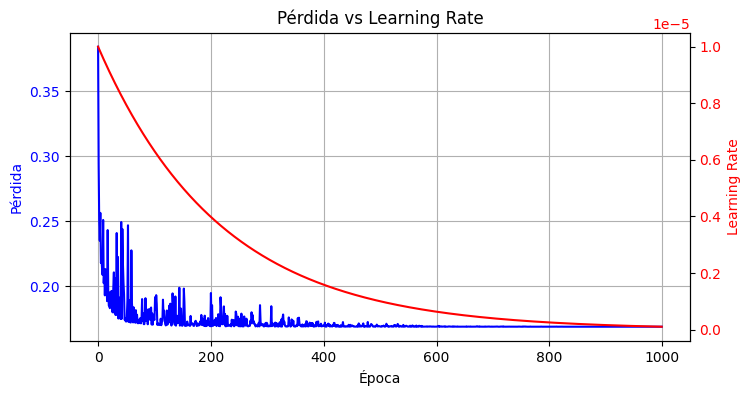

*   Configuracion actual a 1000 epocas.
*   Perdida 0.161



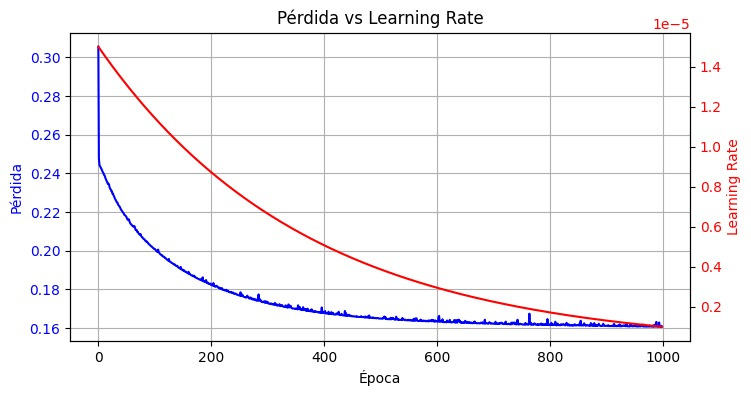

# 9. Referencias

Dive into Deep Learning